In [1]:
import sys
import tensorflow as tf
import numpy as np

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)


Python: C:\Users\91951\anaconda3\python.exe
NumPy: 1.26.4
TensorFlow: 2.19.0


In [2]:
print("Hello Jupyter")


Hello Jupyter


In [3]:
import os

print("Train dir exists:", os.path.exists(r"C:\Users\91951\Downloads\trainfood"))
print("Test dir exists:", os.path.exists(r"C:\Users\91951\Downloads\testfood"))

print("Train classes:", os.listdir(r"C:\Users\91951\Downloads\trainfood"))


Train dir exists: True
Test dir exists: True
Train classes: ['chicken_curry', 'Chiken Biryani', 'Chiken Tanduri', 'Crispy Chicken']


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [5]:
# Define paths and parameters
train_dir = r"C:\Users\91951\Downloads\trainfood"
test_dir = r"C:\Users\91951\Downloads\testfood"


In [6]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)


In [7]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2405 images belonging to 4 classes.
Found 600 images belonging to 4 classes.


In [8]:
# Build custom CNN model from scratch
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes
])


C:\Users\91951\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)


C:\Users\91951\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.3548 - loss: 1.7228 - val_accuracy: 0.4150 - val_loss: 1.2559
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.4940 - loss: 1.1267 - val_accuracy: 0.6983 - val_loss: 0.7929
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6413 - loss: 0.8656 - val_accuracy: 0.7417 - val_loss: 0.6564
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7339 - loss: 0.6920 - val_accuracy: 0.6967 - val_loss: 0.7350
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7227 - loss: 0.6502 - val_accuracy: 0.6817 - val_loss: 0.7432
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7629 - loss: 0.6234 - val_accuracy: 0.8100 - val_loss: 0.5070
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7923 - loss: 0.5267 - val_accuracy: 0.8350 - val_loss: 0.4757
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.8167 - loss: 0.4809 - val_accuracy: 0.7733 - val_lo

In [11]:
# Evaluate on test data
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 815 images belonging to 4 classes.


In [12]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc:.4f}')


26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 390ms/step - accuracy: 0.8821 - loss: 0.3464
Test accuracy: 0.8773


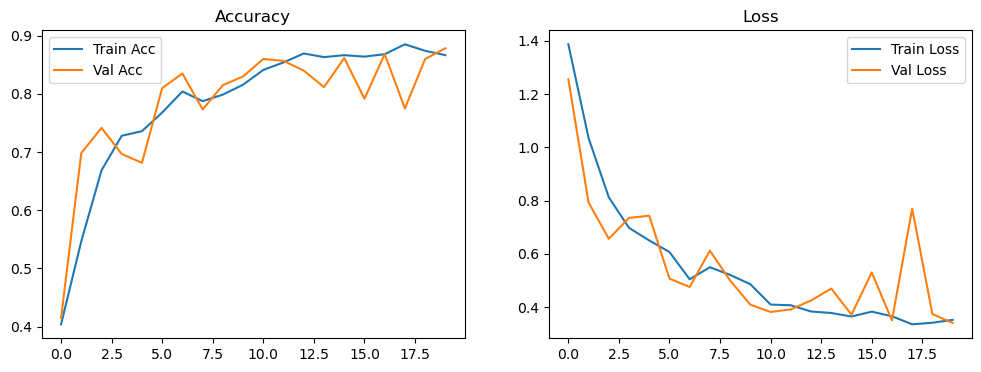

In [13]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()


In [14]:
# Save the model
model.save('custom_4class_model.h5')
print("Model from scratch saved as 'custom_4class_model.h5'")

Model from scratch saved as 'custom_4class_model.h5'


In [15]:
import subprocess
import webbrowser
import os
import time

# Streamlit app code for 4 classes with corrected mapping
app_code = '''
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# Load the model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('pretrained_4class_model.h5')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = load_model()

def predict_image(uploaded_file):
    img = Image.open(uploaded_file).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)
    pred = model.predict(img_array)[0]
    class_index = np.argmax(pred)
    class_names = ['Chicken Biryani', 'Chicken Tanduri', 'Crispy Chicken', 'Chicken Curry'] 
    class_name = class_names[class_index]
    confidence = pred[class_index]
    return class_name, confidence

# App layout
st.title('Chicken Food Classifier')

# File uploader
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)
    
    # Make prediction
    class_name, confidence = predict_image(uploaded_file)
    
    # Display results
    st.write(f'**Prediction:** {class_name}')
    st.write(f'**Confidence:** {confidence:.2f}')
    progress = min(confidence * 100, 100)
    st.progress(progress / 100)
    st.write(f'{progress:.0f}% Confidence')
'''

# Save the code to app.py
with open('app.py', 'w') as f:
    f.write(app_code)
print("app.py created successfully!")

# Launch Streamlit
process = subprocess.Popen(['streamlit', 'run', 'app.py', '--server.headless', 'true', '--server.port', '8501'])

# Open browser
webbrowser.open('http://localhost:8501')
print("Streamlit app launched! Check your browser at http://localhost:8501")

app.py created successfully!
Streamlit app launched! Check your browser at http://localhost:8501
